In [8]:
from dataloader import build_loaders
from model import build_model

# IMPORTANT: Samples=5 (the 5 frequency bands), not 200
model = build_model(nb_classes=4, Chans=62, Samples=5)

run_name = "LeaveOneOut_0.1"

In [9]:
train_loader, val_loader = build_loaders(
    data_root   = '/fs/vulcan-projects/fsh_track/jason-bhargav-temp/CMSC472-Final/data',
    val_subject = 1,
    dataset     = 'SEED-IV',
    window_sec  = 1.0,
    sfreq       = 200,
    n_per_class = 8,
)


Building loaders  [cross_subject]  dataset=SEED-IV  feature=de_LDS
  Loading subject 01/15 … 2505 windows
  Loading subject 02/15 … 2505 windows
  Loading subject 03/15 … 2505 windows
  Loading subject 04/15 … 2505 windows
  Loading subject 05/15 … 2505 windows
  Loading subject 06/15 … 2505 windows
  Loading subject 07/15 … 2505 windows
  Loading subject 08/15 … 2505 windows
  Loading subject 09/15 … 2505 windows
  Loading subject 10/15 … 2505 windows
  Loading subject 11/15 … 2505 windows
  Loading subject 12/15 … 2505 windows
  Loading subject 13/15 … 2505 windows
  Loading subject 14/15 … 2505 windows
  Loading subject 15/15 … 2505 windows

  Train : (35070, 62, 5)  labels [9492 9562 8610 7406]
  Val   : (2505, 62, 5)  labels [678 683 615 529]

  Batch size    : 32  (8/class × 4 classes)
  Train batches : 925
  Val   batches : 79



In [10]:
import torch
from model import build_model, EEGDataset, BalancedBatchSampler, Trainer
from losses import ClassificationLoss, ContrastiveLoss, ContrastivePrototype, LeaveOneOutContrastiveLearning

model     = build_model(nb_classes=4, Chans=62, Samples=5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
warmup_epochs=5

trainer = Trainer(
    
    # '''None'''
    # model, ClassificationLoss(), None,
    # optimizer, lambda_con=0.5, warmup_epochs=warmup_epochs, device='cuda'

    # '''Contrastive Loss'''
    # model, ClassificationLoss(), ContrastiveLoss(temperature=0.1),
    # optimizer, lambda_con=0.5, warmup_epochs=5, device='cuda'

    # '''Contrastive Prototype'''
    # model, ClassificationLoss(), ContrastivePrototype(num_classes=4),
    # optimizer, lambda_con=0.5, warmup_epochs=warmup_epochs, device='cuda'

    # '''Contrastive Prototype'''
    model, ClassificationLoss(), LeaveOneOutContrastiveLearning(temperature=0.1),
    optimizer, lambda_con=0.5, warmup_epochs=warmup_epochs, device='cuda'
)
history = trainer.fit(train_loader, val_loader, epochs=50)

Epoch 001/50  train_loss=3.4204  cls=0.0000  con=3.4204  acc=0.245  |  val_loss=3.3928  val_cls=0.0000  val_con=3.3928  val_acc=0.271
Epoch 002/50  train_loss=3.4020  cls=0.0000  con=3.4020  acc=0.244  |  val_loss=3.3938  val_cls=0.0000  val_con=3.3938  val_acc=0.271
Epoch 003/50  train_loss=3.3993  cls=0.0000  con=3.3993  acc=0.230  |  val_loss=3.3923  val_cls=0.0000  val_con=3.3923  val_acc=0.190
Epoch 004/50  train_loss=3.3936  cls=0.0000  con=3.3936  acc=0.209  |  val_loss=3.3892  val_cls=0.0000  val_con=3.3892  val_acc=0.203
Epoch 005/50  train_loss=3.3874  cls=0.0000  con=3.3874  acc=0.216  |  val_loss=3.3923  val_cls=0.0000  val_con=3.3923  val_acc=0.185
Epoch 006/50  train_loss=2.9654  cls=1.2767  con=3.3774  acc=0.385  |  val_loss=3.0545  val_cls=1.3598  val_con=3.3894  val_acc=0.387
Epoch 007/50  train_loss=2.9162  cls=1.2321  con=3.3683  acc=0.424  |  val_loss=3.0507  val_cls=1.3577  val_con=3.3861  val_acc=0.377
Epoch 008/50  train_loss=2.8881  cls=1.2059  con=3.3643  acc=0

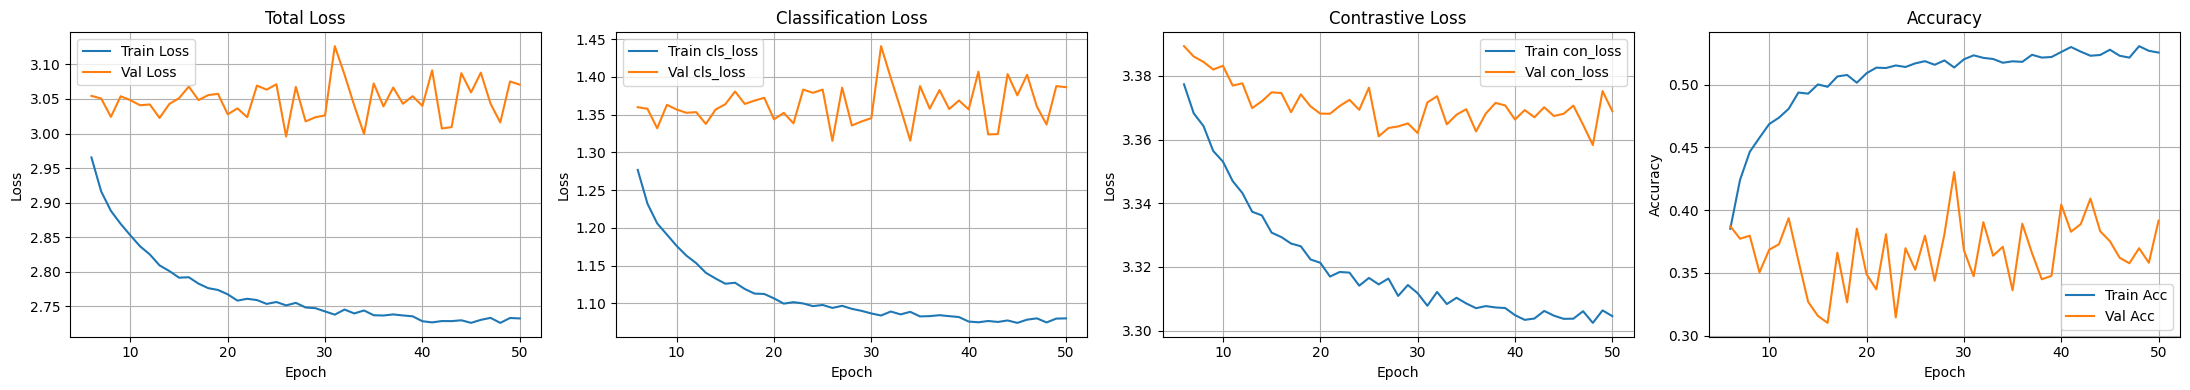

In [11]:
import matplotlib.pyplot as plt
import os

def plot_history(history):
    epochs = range(warmup_epochs + 1, len(history['train']) + 1)

    train_loss     = [e['loss']     for e in history['train']][warmup_epochs:]
    val_loss       = [e['loss']     for e in history['val']][warmup_epochs:]
    train_cls_loss = [e['cls_loss'] for e in history['train']][warmup_epochs:]
    val_cls_loss   = [e['cls_loss'] for e in history['val']][warmup_epochs:]
    train_con_loss = [e['con_loss'] for e in history['train']][warmup_epochs:]
    val_con_loss   = [e['con_loss'] for e in history['val']][warmup_epochs:]
    train_acc      = [e['acc']      for e in history['train']][warmup_epochs:]
    val_acc        = [e['acc']      for e in history['val']][warmup_epochs:]

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    ax1, ax2, ax3, ax4 = axes

    # Total Loss
    ax1.plot(epochs, train_loss, label='Train Loss')
    ax1.plot(epochs, val_loss,   label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Total Loss')
    ax1.legend()
    ax1.grid(True)

    # cls_loss
    ax2.plot(epochs, train_cls_loss, label='Train cls_loss')
    ax2.plot(epochs, val_cls_loss,   label='Val cls_loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Classification Loss')
    ax2.legend()
    ax2.grid(True)

    # con_loss
    ax3.plot(epochs, train_con_loss, label='Train con_loss')
    ax3.plot(epochs, val_con_loss,   label='Val con_loss')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.set_title('Contrastive Loss')
    ax3.legend()
    ax3.grid(True)

    # Accuracy
    ax4.plot(epochs, train_acc, label='Train Acc')
    ax4.plot(epochs, val_acc,   label='Val Acc')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Accuracy')
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()

    save_path = f'checkpoints/{run_name}/plots.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_history(history)

In [12]:
import os

# Save
save_path = f'checkpoints/{run_name}/model.pt'
os.makedirs('checkpoints', exist_ok=True)

torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history'             : history,
}, save_path)

print(f"Model saved to {save_path}")


Model saved to checkpoints/LeaveOneOut_0.1/model.pt


In [13]:
checkpoint = torch.load(f'checkpoints/{run_name}/model.pt', map_location='cuda')

model = build_model(nb_classes=4, Chans=62, Samples=5)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

EEGNetContrastive(
  (encoder): EEGNetEncoder(
    (b1_temporal): Conv2d(1, 8, kernel_size=(1, 2), stride=(1, 1), padding=(0, 1), bias=False)
    (b1_bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (b1_spatial): _DepthwiseConv2d(
      (conv): Conv2d(8, 16, kernel_size=(62, 1), stride=(1, 1), groups=8, bias=False)
    )
    (b1_bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (b1_pool): AvgPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0)
    (b1_drop): Dropout(p=0.5, inplace=False)
    (b2_sep): _SeparableConv2d(
      (depthwise): Conv2d(16, 16, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1), groups=16, bias=False)
      (pointwise): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    )
    (b2_bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (b2_pool): AvgPool2d(kernel_size=(1, 1), stride=(1, 1), padding=0)
    (b2_drop): Dropout(p=0.5, inplac

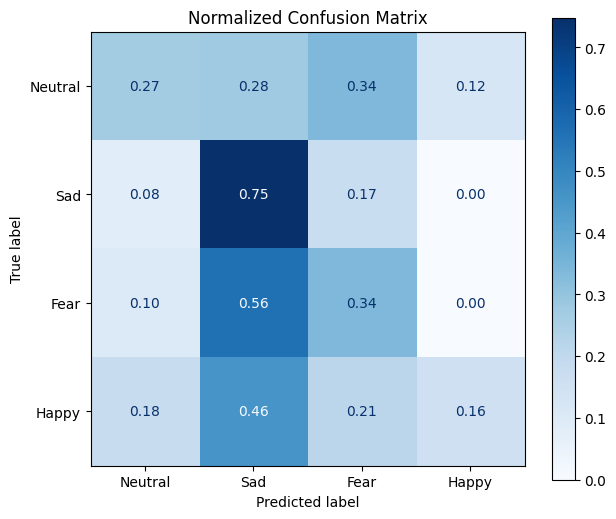

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_normalized_confusion_matrix(model, loader, device='cuda', class_names=None):
    if class_names is None:
        class_names = ['Neutral', 'Sad', 'Fear', 'Happy']

    # FIX: Ensure model is on the same device as the data
    model.to(device)
    model.eval()
    
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            # Handle cases where batch might have 2 or 3 items
            x, labels = batch[0], batch[1]
            
            # Move data to GPU
            x, labels = x.to(device), labels.to(device)
            
            logits, _ = model(x)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ... rest of the plotting code remains the same ...
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=True)
    ax.set_title('Normalized Confusion Matrix')

    os.makedirs(os.path.dirname(f'checkpoints/{run_name}/confusion_matrix.png'), exist_ok=True)
    plt.savefig(f'checkpoints/{run_name}/confusion_matrix.png', dpi=150, bbox_inches='tight')

    plt.show()

# Run it
plot_normalized_confusion_matrix(model, val_loader, device='cuda')
